# Sample restrictions

This notebook reads `sample_flow.csv` produced by the cleaning pipeline and creates:

1. a manuscript-facing sample-restriction table; and
2. a figure showing the number and percentage of submissions remaining after each restriction.

The raw `sample_flow.csv` is left unchanged.

For presentation, the **third recorded stage ("Keep hand-ins with cleaned English text")** is treated as the starting sample and therefore as **100%**. The first two data-assembly stages are not shown.

Recorded stages 5 and 6 are combined into one displayed restriction:
**Keep courses with exam IDs and exam information**.


In [1]:
from pathlib import Path
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================================================
# PATHS
# ================================================================

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"
OUTPUT_PATH = PROJECT_ROOT / "outputs"

PLOT_PATH = OUTPUT_PATH / "figures"
TABLE_PATH = OUTPUT_PATH / "tables"

SAMPLE_FLOW_PATH = DATA_PATH / "sample_flow.csv"
TABLE_OUTPUT = TABLE_PATH / "sample_restrictions.csv"
PLOT_OUTPUT = PLOT_PATH / "sample_restrictions.png"

PLOT_PATH.mkdir(parents=True, exist_ok=True)


## Load the raw sample-flow data

In [2]:
# ================================================================
# LOAD SAMPLE FLOW
# ================================================================

sample_flow = pd.read_csv(SAMPLE_FLOW_PATH)

required_columns = [
    "script",
    "stage",
    "n_submissions",
    "n_removed",
]

missing_columns = [
    col for col in required_columns
    if col not in sample_flow.columns
]

if missing_columns:
    raise KeyError(
        "sample_flow.csv is missing required columns: "
        f"{missing_columns}.\n"
        f"Available columns are: {list(sample_flow.columns)}"
    )

# The CSV is written in pipeline order.
# Create an explicit raw step number for presentation.
sample_flow = sample_flow.reset_index(drop=True).copy()
sample_flow["raw_step"] = np.arange(1, len(sample_flow) + 1)

print(f"Loaded {len(sample_flow):,} recorded sample-flow stages.")
print(f"Columns: {list(sample_flow.columns)}")

display(
    sample_flow[
        [
            "raw_step",
            "script",
            "stage",
            "n_submissions",
            "n_removed",
        ]
    ]
)


Loaded 25 recorded sample-flow stages.
Columns: ['script', 'stage', 'n_submissions', 'n_removed', 'n_students', 'n_courses', 'n_exams', 'n_pre', 'n_post', 'raw_step']


,raw_step,script,stage,n_submissions,n_removed
0,1,5_clean_metadata,Keep KU/RUC observations,794327,430940.0
1,2,5_clean_metadata,Keep hand-ins with a BID in bid_meta,676928,117399.0
2,3,5_clean_metadata,Keep hand-ins with cleaned English text,198949,477979.0
3,4,5_clean_metadata,Remove re-exams,197797,1152.0
4,5,5_clean_metadata,Keep course codes represented in english_cours...,137189,60608.0
5,6,5_clean_metadata,Merge exam information from english_coursedata,135233,1956.0
6,7,5_clean_metadata,Drop hand-ins without an exam label,135125,108.0
7,8,5_clean_metadata,Keep valid dates from 2018 onward,116564,18561.0
8,9,5_clean_metadata,Keep before/after periods and exclude transiti...,114780,1784.0
9,10,5_clean_metadata,Drop incomplete cases on required metadata,114780,0.0


## Construct the displayed sample flow

The third recorded stage is the English-language sample. Its number of remaining submissions is used as the denominator for all percentages.

The display names are changed only here; the underlying `sample_flow.csv` is not modified.

In [3]:
# ================================================================
# CONSTRUCT DISPLAY TABLE
# ================================================================

flow = sample_flow.copy()

# N before a restriction can be reconstructed from the N remaining
# and the number removed. For checkpoint rows with no restriction,
# n_removed is missing, so N before equals N remaining.
flow["n_before"] = np.where(
    flow["n_removed"].notna(),
    flow["n_submissions"] + flow["n_removed"],
    flow["n_submissions"],
)

# ------------------------------------------------
# English-language sample = current raw Step 3
# ------------------------------------------------

english_rows = flow.loc[
    flow["raw_step"] == 3
]

if len(english_rows) != 1:
    raise ValueError(
        "Expected exactly one third recorded sample-flow stage."
    )

english_row = english_rows.iloc[0]

original_n = int(
    english_row["n_submissions"]
)

print(
    f"Starting English-language sample: "
    f"{original_n:,} submissions"
)

# ------------------------------------------------
# Keep only stages after the English-language baseline
# ------------------------------------------------

display_flow = (
    flow.loc[
        flow["raw_step"] > 3
    ]
    .copy()
    .reset_index(drop=True)
)

# ------------------------------------------------
# Merge current raw Steps 5 and 6
# ------------------------------------------------

step5 = flow.loc[
    flow["raw_step"] == 5
].copy()

step6 = flow.loc[
    flow["raw_step"] == 6
].copy()

if len(step5) != 1 or len(step6) != 1:
    raise ValueError(
        "Expected exactly one row each for raw Steps 5 and 6."
    )

merged_row = step6.iloc[0].copy()

merged_row["raw_step"] = 5
merged_row["stage"] = (
    "Keep courses with exam IDs and exam information"
)

# The combined restriction begins before raw Step 5
# and ends after raw Step 6.
merged_row["n_before"] = step5.iloc[0]["n_before"]
merged_row["n_removed"] = (
    merged_row["n_before"]
    - merged_row["n_submissions"]
)

display_flow = display_flow.loc[
    ~display_flow["raw_step"].isin([5, 6])
].copy()

display_flow = pd.concat(
    [
        display_flow,
        pd.DataFrame([merged_row]),
    ],
    ignore_index=True,
)

display_flow = (
    display_flow
    .sort_values("raw_step")
    .reset_index(drop=True)
)

# ------------------------------------------------
# Add English-language baseline
# ------------------------------------------------

baseline = english_row.copy()

baseline["raw_step"] = 0
baseline["stage"] = "English-language submissions"
baseline["n_before"] = original_n
baseline["n_removed"] = 0
baseline["n_submissions"] = original_n

display_flow = pd.concat(
    [
        pd.DataFrame([baseline]),
        display_flow,
    ],
    ignore_index=True,
)

# ------------------------------------------------
# Sequential displayed step numbers
# ------------------------------------------------

display_flow["Step"] = np.arange(
    len(display_flow)
)

# ------------------------------------------------
# Percentages
# ------------------------------------------------

display_flow["Percent of original sample"] = (
    100
    * display_flow["n_submissions"]
    / original_n
).round(1)

display_flow["Percent removed at step"] = np.where(
    display_flow["n_before"] > 0,
    100
    * display_flow["n_removed"].fillna(0)
    / display_flow["n_before"],
    np.nan,
)

display_flow["Percent removed at step"] = (
    display_flow["Percent removed at step"]
    .round(1)
)


Starting English-language sample: 198,949 submissions


## Create and save the sample-restriction table

In [4]:
# ================================================================
# CREATE CLEAN TABLE
# ================================================================

sample_table = pd.DataFrame(
    {
        "Step": display_flow["Step"],
        "Restriction": display_flow["stage"],
        "N before": display_flow["n_before"],
        "N removed": display_flow["n_removed"].fillna(0),
        "Percent removed at step": display_flow[
            "Percent removed at step"
        ],
        "N remaining": display_flow["n_submissions"],
        "Percent of original sample": display_flow[
            "Percent of original sample"
        ],
    }
)

# Add sample-composition columns where available.
optional_columns = {
    "n_students": "N students",
    "n_courses": "N courses",
    "n_exams": "N exams",
    "n_pre": "N pre",
    "n_post": "N post",
}

for source_col, display_col in optional_columns.items():
    if source_col in display_flow.columns:
        sample_table[display_col] = display_flow[source_col]

# Use nullable integers for count columns.
count_columns = [
    "Step",
    "N before",
    "N removed",
    "N remaining",
    "N students",
    "N courses",
    "N exams",
    "N pre",
    "N post",
]

for col in count_columns:
    if col in sample_table.columns:
        sample_table[col] = (
            pd.to_numeric(
                sample_table[col],
                errors="coerce",
            )
            .round()
            .astype("Int64")
        )

display(sample_table)

sample_table.to_csv(
    TABLE_OUTPUT,
    index=False,
)

print(f"Saved table to: {TABLE_OUTPUT}")


,Step,Restriction,N before,N removed,Percent removed at step,N remaining,Percent of original sample,N students,N courses,N exams,N pre,N post
0,0,English-language submissions,198949,0,0.0,198949,100.0,64646,<NA>,<NA>,<NA>,<NA>
1,1,Remove re-exams,198949,1152,0.6,197797,99.4,64520,5614,<NA>,<NA>,<NA>
2,2,Keep courses with exam IDs and exam information,197797,62564,31.6,135233,68.0,50562,2634,6932,116085,17364
3,3,Drop hand-ins without an exam label,135233,108,0.1,135125,67.9,50537,2634,6926,115977,17364
4,4,Keep valid dates from 2018 onward,135125,18561,13.7,116564,58.6,43319,2353,5985,97416,17364
5,5,Keep before/after periods and exclude transiti...,116564,1784,1.5,114780,57.7,42962,2343,5936,97416,17364
6,6,Drop incomplete cases on required metadata,114780,0,0.0,114780,57.7,42962,2343,5936,97416,17364
7,7,Keep take-home examinations,114780,23175,20.2,91605,46.0,39358,1975,4797,77166,14439
8,8,Remove courses that change written exam type b...,91605,3023,3.3,88582,44.5,37768,1958,4767,74185,14397
9,9,Keep courses observed both before and after Ch...,88582,33774,38.1,54808,27.5,28493,664,2587,41791,13017


Saved table to: /work/data_assigments/GAI paper/replication/outputs/tables/sample_restrictions.csv


## Plot sample construction

The bar labels report the number of submissions remaining and the percentage of the English-language starting sample.

Saved plot to: /work/data_assigments/GAI paper/replication/outputs/figures/sample_restrictions.png


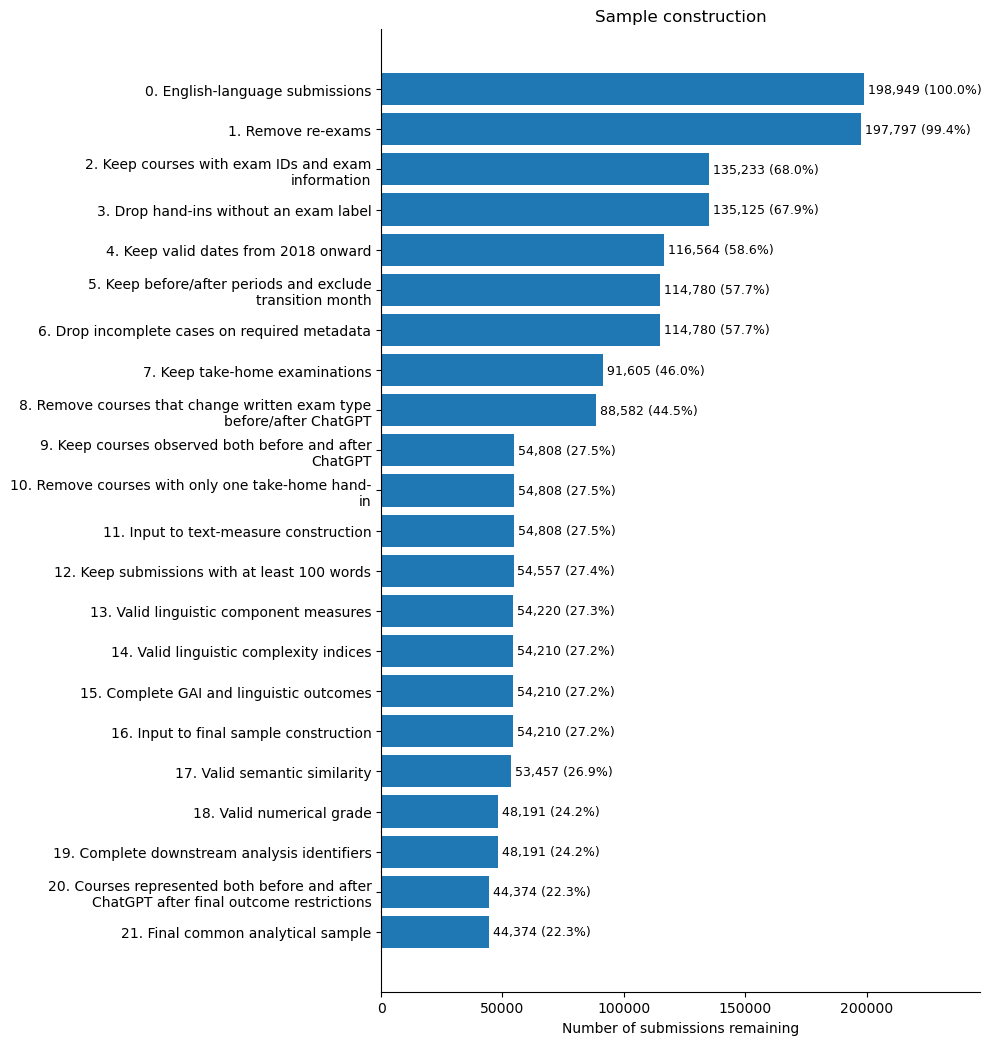

In [5]:
# ================================================================
# PLOT NUMBER OF SUBMISSIONS REMAINING AFTER EACH RESTRICTION
# ================================================================

plot_data = sample_table.copy()

plot_data["Plot label"] = plot_data.apply(
    lambda row: f"{int(row['Step'])}. {row['Restriction']}",
    axis=1,
)

plot_data["Plot label"] = plot_data["Plot label"].map(
    lambda x: textwrap.fill(x, width=48)
)

fig_height = max(
    6,
    0.48 * len(plot_data),
)

fig, ax = plt.subplots(
    figsize=(10, fig_height)
)

bars = ax.barh(
    plot_data["Plot label"],
    plot_data["N remaining"].astype(float),
)

ax.invert_yaxis()

ax.set_xlabel(
    "Number of submissions remaining"
)
ax.set_ylabel("")
ax.set_title(
    "Sample construction"
)

max_n = float(
    plot_data["N remaining"].max()
)

for bar, n, pct in zip(
    bars,
    plot_data["N remaining"],
    plot_data["Percent of original sample"],
):
    ax.text(
        bar.get_width() + max_n * 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{int(n):,} ({pct:.1f}%)",
        va="center",
        fontsize=9,
    )

ax.set_xlim(
    0,
    max_n * 1.24,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

fig.savefig(
    PLOT_OUTPUT,
    dpi=300,
    bbox_inches="tight",
)

print(f"Saved plot to: {PLOT_OUTPUT}")

plt.show()


## Final analytical sample

In [6]:
# ================================================================
# FINAL SAMPLE SUMMARY
# ================================================================

final_row = sample_table.iloc[-1]

print(
    f"Final analytical sample: "
    f"{int(final_row['N remaining']):,} submissions "
    f"({final_row['Percent of original sample']:.1f}% "
    f"of the English-language starting sample)."
)


Final analytical sample: 44,374 submissions (22.3% of the English-language starting sample).


In [7]:
final_row

Step                                                      21
Restriction                   Final common analytical sample
N before                                               44374
N removed                                                  0
Percent removed at step                                  0.0
N remaining                                            44374
Percent of original sample                              22.3
N students                                             25364
N courses                                                479
N exams                                                 1843
N pre                                                  32911
N post                                                 11463
Name: 21, dtype: object